# تدريب CNN من الصفر لتصنيف Chest X-Ray (Pneumonia)
شغّلي الخلايا بالترتيب. عند انقطاع الجلسة: أعيدي تشغيل خلايا الإعداد فقط (1-6)، ثم خلية استئناف التدريب من آخر checkpoint (خلية 10) بدل التدريب من الصفر.

### 1) تثبيت المكتبات

In [1]:
!pip install -q kaggle tensorflow scikit-learn matplotlib seaborn

### 2) ربط Google Drive (لحفظ الـ checkpoints والنموذج النهائي بشكل دائم)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/pneumonia_project'
CKPT_DIR = f'{PROJECT_DIR}/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)
print('مجلد المشروع جاهز في Drive:', PROJECT_DIR)

Mounted at /content/drive
مجلد المشروع جاهز في Drive: /content/drive/MyDrive/pneumonia_project


### 3) بيانات دخول Kaggle

In [3]:
from getpass import getpass

KAGGLE_USERNAME = input('اكتبي Kaggle Username: ').strip()
KAGGLE_KEY = getpass('ألصقي Kaggle API Key هنا ثم اضغطي Enter: ').strip()

if not KAGGLE_USERNAME or not KAGGLE_KEY:
    raise ValueError('لازم تدخلي اسم المستخدم والمفتاح معاً.')

os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
os.environ['KAGGLE_KEY'] = KAGGLE_KEY
print('تم إعداد Kaggle API بنجاح')

اكتبي Kaggle Username: safaa66
ألصقي Kaggle API Key هنا ثم اضغطي Enter: ··········
تم إعداد Kaggle API بنجاح


### 4) تنظيف أي نسخة قديمة

In [4]:
import shutil
from pathlib import Path

zip_path = Path('/content/chest-xray-pneumonia.zip')
data_path = Path('/content/chest_xray')

if zip_path.exists():
    zip_path.unlink()
if data_path.exists():
    shutil.rmtree(data_path)
print('تم تجهيز المسار')

تم تجهيز المسار


### 5) تنزيل الـ Dataset

In [5]:
import subprocess

print('جاري التنزيل...')
result = subprocess.run([
    'kaggle', 'datasets', 'download',
    '-d', 'paultimothymooney/chest-xray-pneumonia',
    '-p', '/content'
])
if result.returncode != 0:
    raise RuntimeError('فشل التنزيل. تأكدي من صحة Username/Key وتفعيل رقم الهاتف بحساب Kaggle.')

جاري التنزيل...


### 6) فك الضغط

In [6]:
subprocess.run([
    'unzip', '-q', '-o', '/content/chest-xray-pneumonia.zip', '-d', '/content'
], check=True)
print('تم التنزيل وفك الضغط')
print('المسار:', '/content/chest_xray')

تم التنزيل وفك الضغط
المسار: /content/chest_xray


### 7) تجهيز البيانات (Grayscale + CLAHE + تقسيم مريض 65/20/15)
أضفنا **CLAHE** (تحسين تباين موحّد) كخطوة معالجة مسبقة — تطبّع الإضاءة والتباين لكل صورة بغض النظر عن مصدرها أو جهاز التصوير، وهذا يقلل فجوة الأداء لما نختبر على صور من مصادر خارجية (مثل الإنترنت) بعيدة عن توزيع بيانات Kaggle الأصلية. لازم نطبّقها بنفس الطريقة وقت التدريب ووقت أي تنبؤ لاحق.

In [7]:
import os
import re
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 64
base_dir = '/content/chest_xray'

def apply_clahe(img_array):
    """تحسين تباين موحّد — يطبَّق على كل صورة قبل أي معالجة ثانية."""
    img_uint8 = img_array.astype('uint8')
    if img_uint8.ndim == 3 and img_uint8.shape[-1] == 1:
        img_uint8 = img_uint8[:, :, 0]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_uint8)
    img_clahe = np.expand_dims(img_clahe, axis=-1).astype('float32')
    return img_clahe

def collect_filepaths(base_dir):
    records = []
    for split in ['train', 'val', 'test']:
        for label in ['NORMAL', 'PNEUMONIA']:
            folder = os.path.join(base_dir, split, label)
            if not os.path.isdir(folder):
                continue
            for fname in os.listdir(folder):
                fpath = os.path.join(folder, fname)
                if os.path.isfile(fpath):
                    records.append({'filepath': fpath, 'label': label})
    return pd.DataFrame(records)

def extract_patient_id(filepath):
    fname = os.path.basename(filepath)
    m = re.search(r'person(\d+)', fname)
    if m:
        return f'person_{m.group(1)}'
    m = re.search(r'IM-(\d+)', fname)
    if m:
        return f'im_{m.group(1)}'
    return fname

df = collect_filepaths(base_dir)
df['patient_id'] = df['filepath'].apply(extract_patient_id)

print('إجمالي الصور:', len(df))
print('إجمالي المرضى الفريدين:', df['patient_id'].nunique())
print(df['label'].value_counts())

patient_labels = df.groupby('patient_id')['label'].agg(lambda x: x.mode()[0]).reset_index()

train_patients, temp_patients = train_test_split(
    patient_labels, test_size=0.35, stratify=patient_labels['label'], random_state=42
)
val_patients, test_patients = train_test_split(
    temp_patients, test_size=(15/35), stratify=temp_patients['label'], random_state=42
)

train_df = df[df['patient_id'].isin(train_patients['patient_id'])]
val_df = df[df['patient_id'].isin(val_patients['patient_id'])]
test_df = df[df['patient_id'].isin(test_patients['patient_id'])]

print('صور تدريب:', len(train_df), '| صور تحقق:', len(val_df), '| صور اختبار:', len(test_df))

train_datagen = ImageDataGenerator(
    preprocessing_function=apply_clahe,
    rescale=1./255,
    rotation_range=4,
    zoom_range=0.08,
    width_shift_range=0.04,
    height_shift_range=0.04,
    horizontal_flip=False
)
val_test_datagen = ImageDataGenerator(
    preprocessing_function=apply_clahe,
    rescale=1./255
)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', color_mode='grayscale'
)
val_gen = val_test_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', color_mode='grayscale'
)
test_gen = val_test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label', target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode='binary', color_mode='grayscale', shuffle=False
)

print('الفئات:', train_gen.class_indices)

إجمالي الصور: 5856
إجمالي المرضى الفريدين: 2790
label
PNEUMONIA    4273
NORMAL       1583
Name: count, dtype: int64
صور تدريب: 3789 | صور تحقق: 1142 | صور اختبار: 925
Found 3789 validated image filenames belonging to 2 classes.
Found 1142 validated image filenames belonging to 2 classes.
Found 925 validated image filenames belonging to 2 classes.
الفئات: {'NORMAL': 0, 'PNEUMONIA': 1}


### 7.5) تفعيل Mixed Precision + التأكد من استخدام GPU
`mixed_float16` يسرّع التدريب بشكل كبير على GPU مثل T4 (يستخدم دقة أقل للحسابات الداخلية بدون التأثير على الجودة عملياً).

In [ ]:
import tensorflow as tf

print('GPU متاح:', tf.config.list_physical_devices('GPU'))
!nvidia-smi --query-gpu=name,memory.used,memory.total --format=csv

tf.keras.mixed_precision.set_global_policy('mixed_float16')
print('تم تفعيل mixed precision:', tf.keras.mixed_precision.global_policy())

GPU متاح: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
name, memory.used [MiB], memory.total [MiB]
Tesla T4, 3 MiB, 15360 MiB
تم تفعيل mixed precision: <DTypePolicy "mixed_float16">


### 8) بناء نموذج CNN من الصفر (Grayscale، بدون Transfer Learning)
قاعدة Conv مبنية يدوياً بالكامل تستقبل صورة بقناة رمادية وحدة (1) بدل RGB، متبوعة بنفس الرأس الناجح.

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn(input_shape=(224, 224, 1)):
    model = models.Sequential([
        # قاعدة استخراج السمات (Feature Extractor) — مبنية يدوياً بالكامل، بدون أي أوزان جاهزة
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        # نفس "الرأس" اللي نجح سابقاً بدون overfitting
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.35),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.25),
        layers.Dense(1, activation='sigmoid', name='pneumonia_probability', dtype='float32')
    ])
    return model

model = build_cnn()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pneumonia_probability (Dense)   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,577 (971.00 KB)

 Trainable params: 248,577 (971.00 KB)

 Non-trainable params: 0 (0.00 B)

### 9) الـ Callbacks: Checkpoint + Early Stopping + تقليل Learning Rate
- `ModelCheckpoint` يحفظ أفضل نسخة في Drive بعد كل epoch (استئناف عند انقطاع Colab).
- `EarlyStopping` يوقف التدريب لو توقف تحسّن val_loss (يمنع overfitting).
- `ReduceLROnPlateau` يقلل معدل التعلم تلقائياً عند الركود (يساعد يتجنب underfitting).

In [10]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint_path = f'{CKPT_DIR}/cnn_checkpoint_v3.keras'

callbacks = [
    # نراقب val_loss هذي المرة (بدل val_auc) عشان نضمن أقل خسارة ممكنة، مو بس أعلى AUC
    ModelCheckpoint(checkpoint_path, monitor='val_loss', mode='min', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', mode='min', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1)
]

### 10) استئناف التدريب من آخر Checkpoint (إذا انقطعت الجلسة)
شغّلي هذي الخلية فقط لو عندك checkpoint محفوظ سابقاً وتبين تكملين بدل التدريب من الصفر. إذا هذي أول مرة، تجاهليها وروحي للخلية التالية مباشرة.

In [11]:
import os
if os.path.exists(checkpoint_path):
    model = tf.keras.models.load_model(checkpoint_path)
    print('تم استرجاع آخر checkpoint، التدريب سيكمل من هنا')
else:
    print('لا يوجد checkpoint سابق، سيبدأ التدريب من الصفر')

تم استرجاع آخر checkpoint، التدريب سيكمل من هنا


### 10.5) حساب أوزان الفئات (Class Weights)
الـ Dataset فيه عدد صور PNEUMONIA أكبر من NORMAL، فنعطي وزن أعلى للفئة الأقل حتى ما ينحاز النموذج لها — هذا يقلل overfitting الناتج عن عدم توازن البيانات.

In [12]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_gen.classes)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_gen.classes)
class_weight_dict = dict(zip(classes, weights))
print('أوزان الفئات:', class_weight_dict, '|', train_gen.class_indices)

أوزان الفئات: {np.int64(0): np.float64(1.8411078717201166), np.int64(1): np.float64(0.6864130434782608)} | {'NORMAL': 0, 'PNEUMONIA': 1}


### 11) التدريب

In [13]:
EPOCHS = 60

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 847ms/step - accuracy: 0.8549 - auc: 0.9349 - loss: 0.3275 - precision: 0.9583 - recall: 0.8363
Epoch 1: val_loss improved from None to 0.23926, saving model to /content/drive/MyDrive/pneumonia_project/checkpoints/cnn_checkpoint_v3.keras

Epoch 1: finished saving model to /content/drive/MyDrive/pneumonia_project/checkpoints/cnn_checkpoint_v3.keras
60/60 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.8680 - auc: 0.9417 - loss: 0.3041 - precision: 0.9650 - recall: 0.8496 - val_accuracy: 0.8967 - val_auc: 0.9704 - val_loss: 0.2393 - val_precision: 0.9762 - val_recall: 0.8807 - learning_rate: 0.0010
Epoch 2/60
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.8909 - auc: 0.9537 - loss: 0.2719 - precision: 0.9645 - recall: 0.8831
Epoch 2: val_loss did not improve from 0.23926
60/60 ━━━━━━━━━━━━━━━━━━━━ 50s 840ms/step - accuracy: 0.8870 - auc: 0.9518 - loss: 0.2751 - precision: 0.9660 - recall: 0.8757 - val_accuracy: 0.8792 - val_auc: 0.9750 - va

### 12) رسم منحنيات Accuracy/Loss (للتأكد من عدم وجود Overfitting أو Underfitting)
لو منحنى val_loss بدأ يرتفع بينما train_loss يستمر بالنزول = overfitting.
لو الاثنين عالين وما يتحسنون = underfitting (يحتاج نموذج أعقد أو تدريب أطول).

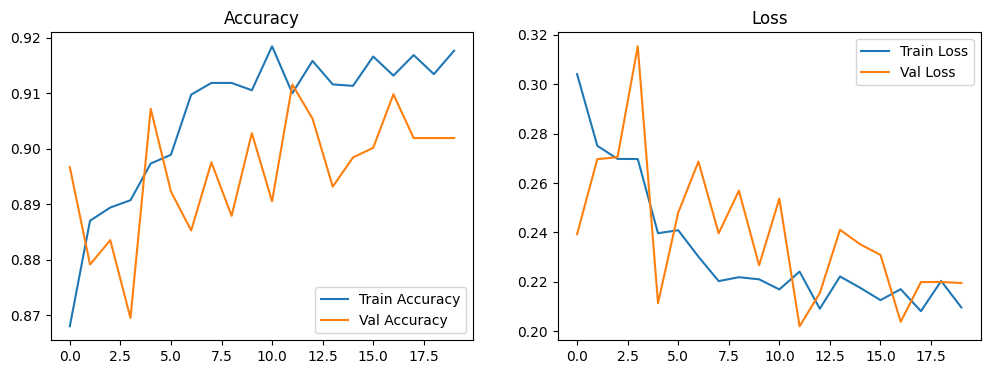

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss')
axes[1].legend()

plt.savefig(f'{PROJECT_DIR}/training_curves.png')
plt.show()

### 12.5) قياس رقمي صريح لفجوة Overfitting (دليل قدام المناقشة)
المعيار الأكاديمي المعتمد: overfitting حقيقي يعني فجوة accuracy بين train وval أكبر من 10-15%. هذي الخلية تحسب الفجوة بالضبط وتحكم تلقائياً.

In [15]:
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

acc_gap = abs(final_train_acc - final_val_acc)
loss_gap = abs(final_train_loss - final_val_loss)

print(f'Train Accuracy: {final_train_acc:.4f}  |  Val Accuracy: {final_val_acc:.4f}  |  الفجوة: {acc_gap:.4f}')
print(f'Train Loss:     {final_train_loss:.4f}  |  Val Loss:     {final_val_loss:.4f}  |  الفجوة: {loss_gap:.4f}')

if acc_gap < 0.05 and loss_gap < 0.15:
    print('\n✅ الفجوة صغيرة → لا يوجد overfitting واضح (حسب المعيار الأكاديمي: فجوة accuracy أقل من 5%)')
else:
    print('\n⚠️ الفجوة كبيرة نسبياً → يُنصح بمزيد من الـ regularization')

Train Accuracy: 0.9177  |  Val Accuracy: 0.9019  |  الفجوة: 0.0157
Train Loss:     0.2096  |  Val Loss:     0.2195  |  الفجوة: 0.0099

✅ الفجوة صغيرة → لا يوجد overfitting واضح (حسب المعيار الأكاديمي: فجوة accuracy أقل من 5%)


### 13) اختبار النموذج على بيانات الاختبار (Test Set)
تقرير كامل: Accuracy, Precision, Recall, F1-score, Confusion Matrix.

15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 613ms/step - accuracy: 0.9124 - auc: 0.9805 - loss: 0.2203 - precision: 0.9885 - recall: 0.8904
Test Accuracy (عتبة افتراضية 0.5): 0.9124
Test AUC: 0.9805
Test Precision (عتبة 0.5): 0.9885
Test Recall (عتبة 0.5): 0.8904
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 435ms/step

=== التقرير الرسمي بالعتبة المعتمدة (0.3) ===
              precision    recall  f1-score   support

      NORMAL       0.81      0.92      0.86       250
   PNEUMONIA       0.97      0.92      0.94       675

    accuracy                           0.92       925
   macro avg       0.89      0.92      0.90       925
weighted avg       0.93      0.92      0.92       925



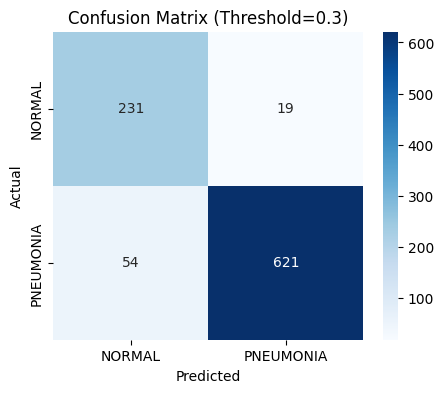

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

FINAL_THRESHOLD = 0.3  # العتبة المعتمدة بعد تجربة Threshold Tuning

test_loss, test_acc, test_auc, test_prec, test_rec = model.evaluate(test_gen)
print(f'Test Accuracy (عتبة افتراضية 0.5): {test_acc:.4f}')
print(f'Test AUC: {test_auc:.4f}')
print(f'Test Precision (عتبة 0.5): {test_prec:.4f}')
print(f'Test Recall (عتبة 0.5): {test_rec:.4f}')

y_pred_probs = model.predict(test_gen)
y_pred = (y_pred_probs > FINAL_THRESHOLD).astype(int).flatten()
y_true = test_gen.classes 

print(f'\n=== التقرير الرسمي بالعتبة المعتمدة ({FINAL_THRESHOLD}) ===')
print(classification_report(y_true, y_pred, target_names=list(test_gen.class_indices.keys())))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_gen.class_indices.keys(),
            yticklabels=test_gen.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Threshold={FINAL_THRESHOLD})')
plt.savefig(f'{PROJECT_DIR}/confusion_matrix.png')
plt.show()

### 13.5) ضبط عتبة القرار (Threshold Tuning)
بدل اعتماد 0.5 كحد فاصل، نجرب عتبات أقل عشان نرفع Recall لفئة PNEUMONIA (نقلل الحالات اللي يفوتها النموذج) — بدون أي إعادة تدريب، بس تغيير قاعدة القرار على نفس تنبؤات النموذج الحالي.

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

thresholds = [0.5, 0.4, 0.35, 0.3, 0.25]
print(f"{'Threshold':<10}{'Accuracy':<10}{'Recall(PNEUMONIA)':<20}{'Precision(PNEUMONIA)':<22}{'F1':<10}")

for t in thresholds:
    y_pred_t = (y_pred_probs > t).astype(int).flatten()
    acc = accuracy_score(y_true, y_pred_t)
    rec = recall_score(y_true, y_pred_t)
    prec = precision_score(y_true, y_pred_t)
    f1 = f1_score(y_true, y_pred_t)
    print(f"{t:<10}{acc:<10.4f}{rec:<20.4f}{prec:<22.4f}{f1:<10.4f}")

print('\nاختاري العتبة اللي تعطي أعلى Recall بدون ما تنزل Precision كثير — عادة 0.3 أو 0.35 خيار متوازن بالتطبيقات الطبية.')

Threshold Accuracy  Recall(PNEUMONIA)   Precision(PNEUMONIA)  F1        
0.5       0.9124    0.8904              0.9885                0.9369    
0.4       0.9178    0.9067              0.9792                0.9415    
0.35      0.9189    0.9126              0.9747                0.9426    
0.3       0.9211    0.9200              0.9703                0.9445    
0.25      0.9265    0.9333              0.9648                0.9488    

اختاري العتبة اللي تعطي أعلى Recall بدون ما تنزل Precision كثير — عادة 0.3 أو 0.35 خيار متوازن بالتطبيقات الطبية.


### 15) حفظ النموذج النهائي (في Google Drive + تنزيل نسخة للابتوب)
بعد الحفظ في Drive، الخلية بتفتح نافذة تحميل بالمتصفح تخليك تختارين المجلد على جهازك مباشرة.

In [19]:
final_model_path = f'{PROJECT_DIR}/pneumonia_cnn_final.keras'
model.save(final_model_path)
print('تم حفظ النموذج النهائي في Drive:', final_model_path)

# تنزيل نسخة مباشرة للابتوب — المتصفح يفتح نافذة تختارين فيها مكان الحفظ
# (لازم يكون إعداد المتصفح على "Ask where to save each file before downloading")
from google.colab import files
files.download(final_model_path)
print('راح تفتح نافذة تحميل بالمتصفح، اختاري مكان الحفظ باللابتوب')

تم حفظ النموذج النهائي في Drive: /content/drive/MyDrive/pneumonia_project/pneumonia_cnn_final.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

راح تفتح نافذة تحميل بالمتصفح، اختاري مكان الحفظ باللابتوب


---
## 16) واجهة اختبار تفاعلية (Gradio)
ارفعي عدة صور أشعة دفعة وحدة، وبيرجع لكل صورة: طبيعية / ملتهبة، أو تنبيه إذا الصورة مو أشعة أصلاً — مع نسبة الثقة.

### 16.1) تثبيت Gradio

In [20]:
!pip install -q gradio

### 16.2) تحميل النموذج المحفوظ
لو جلستك الحالية فيها المتغير `model` جاهز من التدريب، ما تحتاجين هذي الخلية. لو جلسة جديدة، شغّليها لاسترجاع النموذج من Drive.

In [ ]:
import tensorflow as tf
import os

PROJECT_DIR = '/content/drive/MyDrive/pneumonia_project'
final_model_path = f'{PROJECT_DIR}/pneumonia_cnn_final.keras'
IMG_SIZE = (224, 224)

if 'model' not in globals():
    from google.colab import drive
    drive.mount('/content/drive')
    model = tf.keras.models.load_model(final_model_path)
    print('تم تحميل النموذج من Drive')
else:
    print('النموذج موجود بالذاكرة، لا حاجة لإعادة التحميل')

النموذج موجود بالذاكرة، لا حاجة لإعادة التحميل


### 16.3) دالة التحقق "هل الصورة أشعة أصلاً؟"
صور الأشعة تكون رمادية عملياً (قنوات R وG وB شبه متطابقة لكل بكسل). أي صورة عادية (منظر، وجه، حيوان...) تكون فيها فروقات ألوان واضحة بين القنوات.
هذا فحص مبدئي (heuristic) وليس نموذج مدرّب، ممكن تعدّلين قيمة `threshold` لو لاحظتي أخطاء.

In [22]:
import numpy as np
from PIL import Image

def looks_like_xray(pil_img: Image.Image, threshold: float = 12.0) -> bool:
    rgb = pil_img.convert('RGB')
    arr = np.array(rgb).astype(np.float32)
    diff = (
        np.abs(arr[..., 0] - arr[..., 1]) +
        np.abs(arr[..., 1] - arr[..., 2]) +
        np.abs(arr[..., 0] - arr[..., 2])
    )
    return diff.mean() < threshold

### 16.4) دالة التنبؤ لصورة واحدة

In [23]:
def predict_image(pil_img: Image.Image, threshold: float = 0.3):
    if not looks_like_xray(pil_img):
        return {
            'is_xray': False,
            'label': 'ليست صورة أشعة',
            'confidence': None,
            'color': '#9e9e9e'
        }

    import cv2
    img = pil_img.convert('L').resize(IMG_SIZE)
    arr_raw = np.array(img).astype('uint8')
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    arr_clahe = clahe.apply(arr_raw)
    arr = arr_clahe.astype(np.float32) / 255.0
    arr = np.expand_dims(arr, axis=(0, -1))

    prob = float(model.predict(arr, verbose=0)[0][0])

    if prob > threshold:
        label = 'ملتهبة (Pneumonia)'
        confidence = prob
        color = '#e53935'
    else:
        label = 'طبيعية (Normal)'
        confidence = 1 - prob
        color = '#43a047'

    return {
        'is_xray': True,
        'label': label,
        'confidence': confidence,
        'color': color
    }

### 16.5) بناء واجهة Gradio (رفع عدة صور دفعة وحدة)

In [24]:
import gradio as gr
import base64
from io import BytesIO

def image_to_base64(pil_img, size=(220, 220)):
    thumb = pil_img.copy()
    thumb.thumbnail(size)
    buffer = BytesIO()
    thumb.convert('RGB').save(buffer, format='JPEG', quality=85)
    encoded = base64.b64encode(buffer.getvalue()).decode('utf-8')
    return f'data:image/jpeg;base64,{encoded}'

def build_card(pil_img, result):
    img_b64 = image_to_base64(pil_img)
    color = result['color']
    label = result['label']

    if result['is_xray']:
        pct = result['confidence'] * 100
        confidence_html = f'''
            <div style="background:#eee;border-radius:8px;overflow:hidden;height:14px;margin-top:8px;">
                <div style="background:{color};width:{pct:.1f}%;height:100%;"></div>
            </div>
            <div style="font-size:13px;color:#555;margin-top:4px;">نسبة الثقة: {pct:.1f}%</div>
        '''
    else:
        confidence_html = '<div style="font-size:13px;color:#888;margin-top:8px;">⚠️ الصورة لا تشبه أشعة صدرية</div>'

    return f'''
    <div style="display:inline-block;width:230px;margin:10px;padding:12px;border-radius:14px;
                box-shadow:0 2px 10px rgba(0,0,0,0.15);border-top:6px solid {color};
                background:white;text-align:center;vertical-align:top;">
        <img src="{img_b64}" style="width:100%;border-radius:8px;"/>
        <div style="font-weight:bold;color:{color};margin-top:10px;font-size:15px;">{label}</div>
        {confidence_html}
    </div>
    '''

def run_batch_prediction(files):
    if not files:
        return '<p style="color:#888;">ارفعي صورة وحدة أو أكثر ثم اضغطي ابدأي الاختبار.</p>'

    cards = []
    for f in files:
        pil_img = Image.open(f.name)
        result = predict_image(pil_img)
        cards.append(build_card(pil_img, result))

    return f'<div style="direction:rtl;text-align:right;">{"".join(cards)}</div>'

custom_css = '''
#title_md {text-align:center;}
'''

with gr.Blocks(css=custom_css, title='اختبار نموذج الأشعة الصدرية') as demo:
    gr.Markdown('# 🩻 اختبار نموذج تشخيص الالتهاب الرئوي', elem_id='title_md')
    gr.Markdown('ارفعي عدة صور أشعة صدرية دفعة وحدة — النموذج يحدد لكل صورة: **طبيعية** أو **ملتهبة**، أو ينبّهك إذا الصورة أصلاً مش أشعة صدرية، مع نسبة الثقة.', elem_id='title_md')

    file_input = gr.File(file_count='multiple', label='📤 ارفعي صور الأشعة هنا', file_types=['image'])
    submit_btn = gr.Button('🔍 ابدأي الاختبار', variant='primary')
    output_html = gr.HTML()

    submit_btn.click(fn=run_batch_prediction, inputs=file_input, outputs=output_html)

demo.launch(share=True, debug=False)

/tmp/ipykernel_2395/2668672191.py:55: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=custom_css, title='اختبار نموذج الأشعة الصدرية') as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0ba2b5b3c96e872960.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
